# Generalized Models

- Generalized Linear Models (GLMs)
- Generalized Additive Models (GAMs)

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
%pip install pygam
from pygam import LinearGAM, GammaGAM, s, f


Note: you may need to restart the kernel to use updated packages.


The first step is to upload the csv file data into our dataframe

In [56]:
CSV_FILE = "kaggle_data"

customer_df = pd.read_csv(CSV_FILE)
customer_df.head(10)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## Cleaning up the data

In [57]:
# Checking if there are any repeat customers

unique_customers = customer_df["customerID"].nunique()
rows = customer_df.count()

print(unique_customers)
print(rows["customerID"])

7043
7043


Since the number of unique customers is equal to the number of total customers, we can conclude that there are no repeat customers and thus are safe to remove that column in the dataset.

In [58]:
# Remove customerID

clean_df = customer_df.copy()
clean_df = clean_df.drop(columns=['customerID'])

clean_df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Applying One-Hot Encoding to the categorical variables.

In [59]:
# Normalizing categorical variables
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
clean_df = pd.get_dummies(clean_df, columns=categorical_cols, drop_first=True)
clean_df.head(10)

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,34,56.95,1889.5,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
5,8,99.65,820.5,False,False,False,False,True,False,True,...,True,False,True,False,False,True,False,True,False,True
6,22,89.10,1949.4,True,False,False,True,True,False,True,...,True,False,False,False,False,True,True,False,False,False
7,10,29.75,301.9,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
8,28,104.80,3046.05,False,False,True,False,True,False,True,...,True,False,True,False,False,True,False,True,False,True
9,62,56.15,3487.95,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,False,False


Scaling numerical variables using StandardScaler().

In [105]:
# Scaling numerical variables
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'])
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
clean_df[numerical_cols] = scaler.fit_transform(clean_df[numerical_cols])

clean_df.head(10)


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,-1.277445,-1.160323,-0.994194,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0.066327,-0.259629,-0.173740,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,-1.236724,-0.362660,-0.959649,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0.514251,-0.746535,-0.195248,True,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,-1.236724,0.197365,-0.940457,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
5,-0.992402,1.159546,-0.645369,False,False,False,False,True,False,True,...,True,False,True,False,False,True,False,True,False,True
6,-0.422317,0.808907,-0.147313,True,False,False,True,True,False,True,...,True,False,False,False,False,True,True,False,False,False
7,-0.910961,-1.163647,-0.874169,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
8,-0.177995,1.330711,0.336516,False,False,True,False,True,False,True,...,True,False,True,False,False,True,False,True,False,True
9,1.206498,-0.286218,0.531476,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,False,False


## Exploratory Data Analysis

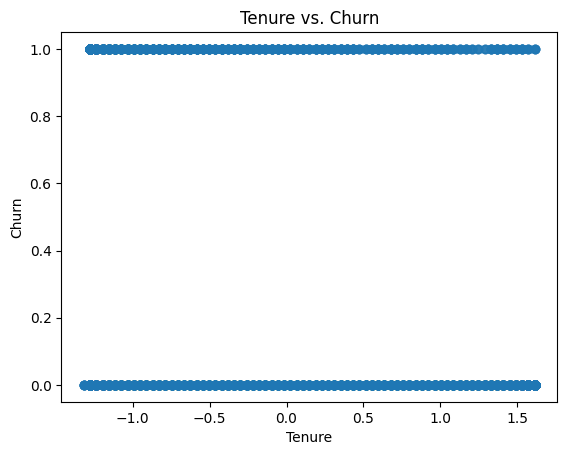

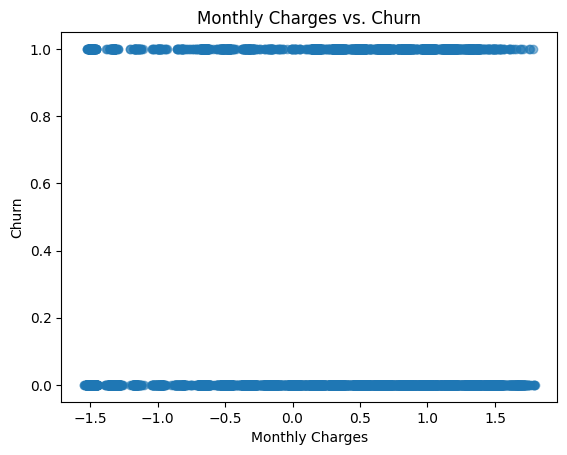

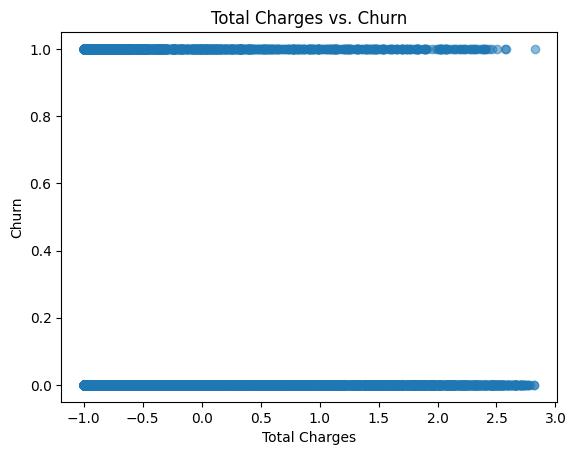

In [106]:
# exploring relationship between numerical variables and churn
plt.scatter(clean_df['tenure'], clean_df['Churn_Yes'], alpha=0.5)
plt.xlabel("Tenure")
plt.ylabel("Churn")
plt.title("Tenure vs. Churn")
plt.show()

plt.scatter(clean_df['MonthlyCharges'], clean_df['Churn_Yes'], alpha=0.5)
plt.xlabel("Monthly Charges")
plt.ylabel("Churn")
plt.title("Monthly Charges vs. Churn")
plt.show()

plt.scatter(clean_df['TotalCharges'], clean_df['Churn_Yes'], alpha=0.5)
plt.xlabel("Total Charges")
plt.ylabel("Churn")
plt.title("Total Charges vs. Churn")
plt.show()


## GAM code


In [ ]:
# Loading the data
non_target = clean_df.drop(columns='Churn_Yes')
X, y = non_target, clean_df['Churn_Yes']

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initializing GAM set-up
gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + f(4), f(5), f(6), f(6), f(7), f(8), f(9), f(10), f(11), f(12), f(13), f(14), f(15), f(16), f(17), f(18))

lams = 

# Finds best smoothing parameter for each spline term
gam.gridsearch(X_train, y_train, lam=lam_grid)

# Fit the model
gam.fit(X_train, y_train)

# Make predictions
y_pred_gam = gam.predict(X_test)

# Calculate MSE and R^2
mse_gam = mean_squared_error(y_test, y_pred_gam)
r2_gam = r2_score(y_test, y_pred_gam)

print(f"GAM MSE: {mse_gam:.4f}, R^2: {r2_gam:.4f}")

gam.summary()


ValueError: X data must not contain Inf nor NaN